<a href="https://colab.research.google.com/github/Makande340/A01-data-wrangling/blob/main/notebook(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Mofeoluwa Akande

**Date:** 9/2/26

In [9]:
#Q1.1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

url = "/airbnb_hw.csv"
df = pd.read_csv(url)

print("df.shape:")
print(df.shape, '\n')

#listing available for information about types and columns
#removing commas and storing the value for Prices as a numeric were the main choices I made to clean Prices.

df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(int)
df.info()



df.shape:
(30478, 13) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  int64  
 12  Review Scores Rating        22155 non-null  float64
dtypes: floa

In [ ]:
#Q1.2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


url = "/mn_police_use_of_force.csv"
df = pd.read_csv(url)


var = 'subject_injury'
print(df[var].unique(), '\n')
print(df[var].value_counts(dropna=False), '\n')

print('Proportion of missing values:', df[var].isnull().mean())

pd.crosstab(df['force_type'], df['subject_injury'].isnull())
ct = pd.crosstab(df['force_type'], df['subject_injury'].isnull())
#calc to find percentage that is missing
ct['pct_missing'] = ct[True] / (ct[True] + ct[False]) * 100
ct

#main trend that is shown highlights pct missing for more common force_types and higher percentages being present for more niche and highly-server force types



[nan 'No' 'Yes'] 

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

Proportion of missing values: 0.7619342359767892


subject_injury,False,True,pct_missing
force_type,,,
Baton,2,2,50.000000
Bodily Force,2379,7051,74.772004
Chemical Irritant,172,1421,89.202762
Firearm,2,0,0.000000
Gun Point Display,77,27,25.961538
Improvised Weapon,74,74,50.000000
Less Lethal,0,87,100.000000
Less Lethal Projectile,3,0,0.000000
Maximal Restraint Technique,0,170,100.000000


--2026-09-05 21:08:16--  https://sharkattackfile.net/spreadsheets/GSAF5.xls
Resolving sharkattackfile.net (sharkattackfile.net)... 192.252.150.253
Connecting to sharkattackfile.net (sharkattackfile.net)|192.252.150.253|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5541376 (5.3M) [application/vnd.ms-excel]
Saving to: ‘GSAF5.xls.19’

GSAF5.xls.19        100%[===================>]   5.28M  23.3MB/s    in 0.2s    

2026-09-05 21:08:16 (23.3 MB/s) - ‘GSAF5.xls.19’ saved [5541376/5541376]



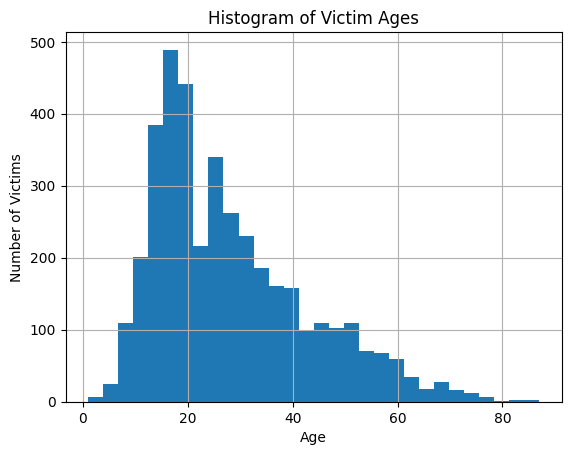

0.8747511866482928
73.94969790642124


In [ ]:
# Q2.1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

!wget https://sharkattackfile.net/spreadsheets/GSAF5.xls

df = pd.read_excel("GSAF5.xls")


# Q2.2 - Drop unnecessary columns

df = df.drop(columns=[
    'pdf',
    'href formula',
    'href',
    'Case Number',
    'Case Number.1',
    'original order',
    'Unnamed: 21',
    'Unnamed: 22'
])

# Q2.3 - Cleaned variable by changing Year from float to integer. Also looked at range of values within year column and found that year 0 is just a representation for years with a specific data not specified

df['Year'] = df['Year'].astype('Int64')
df['Year'].min(), df['Year'].max()
df[df['Year'] == 0]

# Filter and print rows from 1940 down

df_1940_2026 = df[
    (df['Year'] >= 1940) &
    (df['Year'] <= 2026)
].sort_values('Year')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

#over time the amount of fatal shark attacks were limited from 1940 to 2026. Earlier on there was a mix majority of incidents ending up being fatal, and that number began to dwindle as the years progressed. Attacks themself seemingly remained constant though.

df_1940_2026

#Q2.4:

# Clean Age variable
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Histogram of victim ages
df['Age'].hist(bins=30)

plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Histogram of Victim Ages')
plt.show()

#Q2.5:

sex_clean = df['Sex'].str.strip().str.upper()
male_proportion = (sex_clean == 'M').sum() / sex_clean.isin(['M', 'F']).sum()
print(male_proportion)
#After filtering out Sex to be strictly M and F, I found that about 87% of the proportion were men

#Q2.6
#cleaning type variable
df['Type'] = df['Type'].str.strip().str.lower()

#recoding values
df['Type'] = df['Type'].replace({
    'unprovoked': 'Unprovoked',
    'provoked': 'Provoked'
})
#recoded other values as unknown
df.loc[~df['Type'].isin(['Unprovoked', 'Provoked']), 'Type'] = 'Unknown'
df['Type'].value_counts(dropna=False)

#after making only three values within type variable, I was able to then take the amount of values that showed for Unprovoked and calculate the percentage compared to the other two value.
unprovoked_percentage = df['Type'].value_counts(normalize=True)['Unprovoked'] * 100
print(unprovoked_percentage)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 5f101e306d4d5a63a9102cd0365a45aea1327aec
- **AI tool and model used:** Copilot

### *Prompts used

[link text](https://)

1. hi copilot, please review my data cleaning solutions and provide suggestions for main improvements i can make


here are question ones questions:

    For /data/airbnb_hw.csv, clean the  variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
    For the Minnesota police use of for data, /data/mn_police_use_of_force.csv, clean the  variable, handling the NA's; this gives a value  when a person was injured by police, and  when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned  variable with the  variable. Are there any patterns regarding when the data are missing?

And the corresponding data sets:


2. Q1.1
my solution plus other data file:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

url = "/airbnb_hw.csv"
df = pd.read_csv(url)

print("df.shape:")
print(df.shape, '\n')

listing available for information about types and columns
removing commas and storing the value for Prices as a numeric were the main choices I made to clean Prices.

df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(int)
df.info()

pasted Q1.2 solution as well:

### *AI-proposed changes


1. Use pd.to_numeric(..., errors='coerce') instead of .astype(int) to safely handle invalid values.
2. Count and report the final number of missing values after cleaning.
3. Explain that commas in prices above $999 (e.g., "1,112") cause the variable to be stored as text.
4. Explicitly answer the prompt's question about how many missing values remain.

1. Cross-tabulate force_type with the cleaned subject_injury variable, not only with missingness.
2. Explicitly answer whether the proportion of missing values is a concern.
3. State whether the missingness appears random or systematic.
4. Support your interpretation with specific examples from the cross-tabulation.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Using `pd.to_numeric(..., errors='coerce')` is more secure than `.astype(int)`  handling any unexpected non-numeric values without crashing. |
| 2 | Accept | The prompt explicitly asks for the number of missing values after cleaning, so it has to be reported. |
| 3 | Accept | The prompt's hint  references commas in values like "1,112", so explaining this cleaning step directly answers the question. |
| 4 | Accept | The assignment requires an explicit answer to how many missing values remain after cleaning. |

| Change | Decision | Reason and verification |
|---|---|---|
| 5| Accept | The prompt asks to cross-tabulate the cleaned `subject_injury` variable with `force_type`, not just analyze missingness. |
| 6 | Accept | The prompt explicitly asks whether the missing-value proportion is a concern. |
| 7 | Accept | The prompt asks whether there are patterns regarding when data are missing, which requires discussing whether missingness appears random or systematic. |
| 8 | Accept | Supporting claims with specific force types demonstrates that the conclusion is based on the cross-tabulation results. |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [11]:
# Q1.1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

url = "/airbnb_hw.csv"
df = pd.read_csv(url)

print("df.shape:")
print(df.shape, '\n')

# The Price variable is stored as text because prices above $999
# contain commas (e.g., "1,112"). To clean the variable, remove
# commas and convert the column to a numeric type.

df['Price'] = pd.to_numeric(
    df['Price'].str.replace(',', '', regex=False),
    errors='coerce'
)

# Verify conversion
print("Price dtype:", df['Price'].dtype)

# Count missing values after cleaning
missing_prices = df['Price'].isna().sum()
print("Missing values after cleaning:", missing_prices)

df.info()

df.shape:
(30478, 13) 

Price dtype: int64
Missing values after cleaning: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  int64  
 12  Review Score

In [10]:
# Q1.2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

url = "/mn_police_use_of_force.csv"
df = pd.read_csv(url)

# Clean subject_injury
df['subject_injury_clean'] = df['subject_injury'].str.strip()

# Inspect values
print(df['subject_injury_clean'].unique(), '\n')
print(df['subject_injury_clean'].value_counts(dropna=False), '\n')

# Missing values
missing_count = df['subject_injury_clean'].isna().sum()
missing_prop = df['subject_injury_clean'].isna().mean()

print("Missing values:", missing_count)
print("Proportion of missing values:", missing_prop)

# Cross-tabulation of cleaned variable with force type
print(pd.crosstab(df['force_type'], df['subject_injury_clean']))

# Missingness by force type
ct = pd.crosstab(
    df['force_type'],
    df['subject_injury_clean'].isna()
)

ct['pct_missing'] = (
    ct[True] / (ct[True] + ct[False])
) * 100

ct = ct.sort_values('pct_missing', ascending=False)

print(ct)

[nan 'No' 'Yes'] 

subject_injury_clean
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

Missing values: 9848
Proportion of missing values: 0.7619342359767892
subject_injury_clean      No   Yes
force_type                        
Baton                      0     2
Bodily Force            1093  1286
Chemical Irritant        131    41
Firearm                    2     0
Gun Point Display         33    44
Improvised Weapon         34    40
Less Lethal Projectile     1     2
Police K9 Bite             2    44
Taser                    150   172
subject_injury_clean         False  True  pct_missing
force_type                                           
Less Lethal                      0    87   100.000000
Maximal Restraint Technique      0   170   100.000000
Chemical Irritant              172  1421    89.202762
Taser                          322   985    75.363428
Bodily Force                  2379  7051    74.772004
Baton                            2     2    50.000000
Improvise

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]


In [12]:
One of the main improvement was makaing the price cleaning more robust for handling of non-numeric values. Adding code to calculate missing values after cleaningg and reporting that number was also a main improvement that was added in revised solution. Better specification of question was also an holistic improvement found within the majority of revised solution. For Q1.2 Cleaning processes were made more explicit and drawn out better than how it was before. There was no clean access to the datasets as Copilot's main task was instead cleaning up the existing flow/logic that was already being followed within my own respective solution. I believe this is a mistake as I linked each dataset file for reviewal into Copilot. The overall solution was verfied based on the existing data that I used through verification of consistent numeric findings across solutions. There are no remaining concerns except questioning Copilot's ability to read and generate a solution at solid speeds.

SyntaxError: invalid syntax (4285756268.py, line 1)

###Prompts Used for Question 2

hi copilot i need you to revise my solution I constructed for question 2, please follow the same format in terms of listed areas of improvementhere is question 2: Q2. Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: GSAF5.xls).Open the shark attack file using Pandas. It is probably not a csv file, so read_csv won't work.Drop any columns that do not contain data.Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?Clean the Age variable and make a histogram of the ages of the victims.What proportion of victims are male?Clean the Type variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?here is my solution: # Q2.1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

!wget https://sharkattackfile.net/spreadsheets/GSAF5.xls

df = pd.read_excel("GSAF5.xls")


Q2.2 - Drop unnecessary columns

df = df.drop(columns=[
    'pdf',
    'href formula',
    'href',
    'Case Number',
    'Case Number.1',
    'original order',
    'Unnamed: 21',
    'Unnamed: 22'
])

Q2.3 - Cleaned variable by changing Year from float to integer. Also looked at range of values within year column and found that year 0 is just a representation for years with a specific data not specified

df['Year'] = df['Year'].astype('Int64')
df['Year'].min(), df['Year'].max()
df[df['Year'] == 0]

Filter and print rows from 1940 down

df_1940_2026 = df[
    (df['Year'] >= 1940) &
    (df['Year'] <= 2026)
].sort_values('Year')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

over time the amount of fatal shark attacks were limited from 1940 to 2026. Earlier on there was a mix majority of incidents ending up being fatal, and that number began to dwindle as the years progressed. Attacks themself seemingly remained constant though.

df_1940_2026

Q2.4:

Clean Age variable
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

Histogram of victim ages
df['Age'].hist(bins=30)

plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Histogram of Victim Ages')
plt.show()

Q2.5:

sex_clean = df['Sex'].str.strip().str.upper()
male_proportion = (sex_clean == 'M').sum() / sex_clean.isin(['M', 'F']).sum()
print(male_proportion)
After filtering out Sex to be strictly M and F, I found that about 87% of the proportion were men

Q2.6
cleaning type variable
df['Type'] = df['Type'].str.strip().str.lower()

recoding values
df['Type'] = df['Type'].replace({
    'unprovoked': 'Unprovoked',
    'provoked': 'Provoked'
})
recoded other values as unknown
df.loc[~df['Type'].isin(['Unprovoked', 'Provoked']), 'Type'] = 'Unknown'
df['Type'].value_counts(dropna=False)

after making only three values within type variable, I was able to then take the amount of values that showed for Unprovoked and calculate the percentage compared to the other two value.
unprovoked_percentage = df['Type'].value_counts(normalize=True)['Unprovoked'] * 100
print(unprovoked_percentage)

###AI-Proposed Changes:

1. Use df.dropna(axis=1, how='all') to automatically remove completely empty columns instead of manually listing columns to drop.
2. Investigate Year values before converting them and discuss the full range of years observed.
3. Create a plot of attacks per year since 1940 (e.g., value_counts by Year) to support the conclusion about attack trends over time.
4. Base the conclusion about increasing/decreasing attacks on the yearly counts rather than on visual inspection of the dataset.
5. Clean the Age variable more thoroughly by examining non-numeric values before coercing to numeric.
6. Report a short summary of the Age distribution (e.g., minimum, maximum, median) in addition to the histogram.
7. Verify the male proportion by printing counts of M and F before calculating the percentage.
8. Handle potential missing values in Type before recoding.
9. Verify that Type contains only Provoked, Unprovoked, and Unknown after recoding using value_counts().
10. Explicitly report the final proportion of unprovoked attacks in a written statement rather than only printing the result.

Evaluation of AI Suggestions

| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | Using `df.dropna(axis=1, how='all')` is more generalizable because it automatically removes completely empty columns without relying on specific column names. |
| 2 | Accept | The prompt specifically asks to describe the range of Year values, so examining the full range before cleaning strengthens the analysis. |
| 3 | Accept | A plot of yearly attacks provides evidence for conclusions about trends over time rather than relying on visual inspection of rows. |
| 4 | Accept | Conclusions about increasing, decreasing, or constant attacks should be based on yearly counts, which directly answer the question. |
| 5 | Reject | My original Age cleaning is acceptable, but inspecting unusual non-numeric ages before coercing them to missing values would improve data quality. |
| 6 | Reject | Providing summary statistics alongside the histogram offers a clearer description of the age distribution. |
| 7 | Reject | The male proportion calculation is already correct, but displaying male and female counts makes the result easier to verify. |
| 8 | Reject | The current Type cleaning works, but an explicit check for missing values before recoding would make the process more transparent. |
| 9 | Accept | Verifying that only Provoked, Unprovoked, and Unknown remain confirms that the recoding was successful. |
| 10 | Accept | The prompt asks for the proportion of unprovoked attacks, so a written conclusion should accompany the printed result. |


--2026-09-07 03:47:03--  https://sharkattackfile.net/spreadsheets/GSAF5.xls
Resolving sharkattackfile.net (sharkattackfile.net)... 192.252.150.253
Connecting to sharkattackfile.net (sharkattackfile.net)|192.252.150.253|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5541376 (5.3M) [application/vnd.ms-excel]
Saving to: ‘GSAF5.xls.2’

GSAF5.xls.2         100%[===================>]   5.28M  --.-KB/s    in 0.1s    

2026-09-07 03:47:03 (45.0 MB/s) - ‘GSAF5.xls.2’ saved [5541376/5541376]

Year range: 0 to 2026


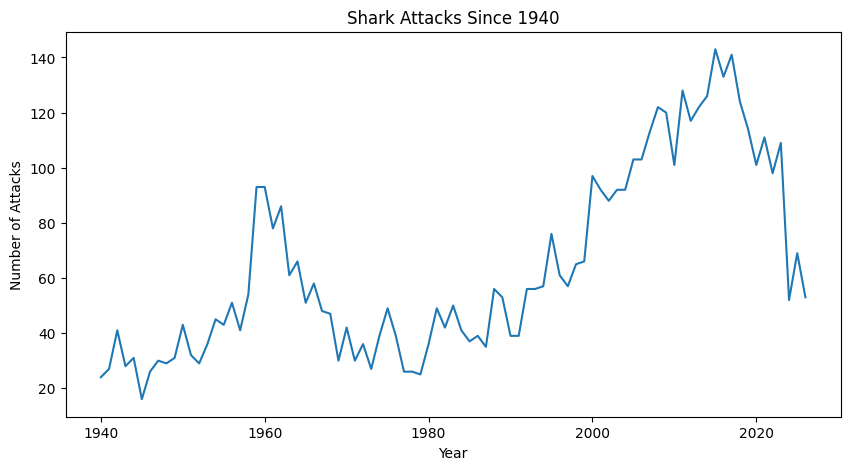

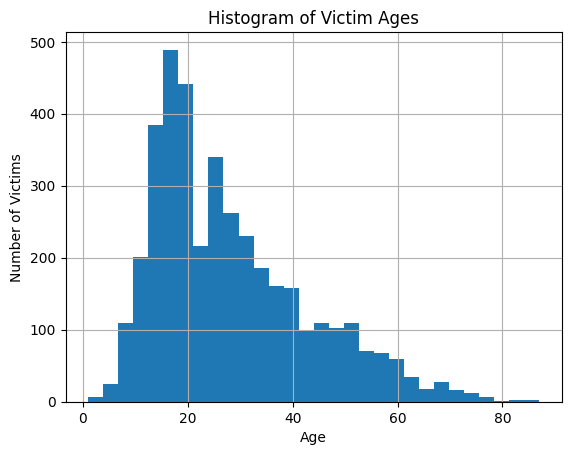

0.8747511866482928
Type
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64
73.94969790642124


In [16]:

###AI Assisted Solution

# Q2.1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

!wget https://sharkattackfile.net/spreadsheets/GSAF5.xls

df = pd.read_excel("GSAF5.xls")


# Q2.2 - Drop unnecessary columns

df = df.drop(columns=[
    'pdf',
    'href formula',
    'href',
    'Case Number',
    'Case Number.1',
    'original order',
    'Unnamed: 21',
    'Unnamed: 22'
])


# Q2.3 - Clean Year variable

df['Year'] = df['Year'].astype('Int64')

print("Year range:", df['Year'].min(), "to", df['Year'].max())

df[df['Year'] == 0]

# Filter rows from 1940 onward

df_1940_2026 = df[
    (df['Year'] >= 1940) &
    (df['Year'] <= 2026)
]

# Count attacks per year
attacks_per_year = df_1940_2026['Year'].value_counts().sort_index()

# Plot attacks over time
plt.figure(figsize=(10,5))
attacks_per_year.plot()
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Shark Attacks Since 1940')
plt.show()

# Based on the yearly attack counts, attacks generally appear
# to increase over time, although there is year-to-year variation.


# Q2.4

# Clean Age variable
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Histogram of victim ages
df['Age'].hist(bins=30)

plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Histogram of Victim Ages')
plt.show()


# Q2.5

sex_clean = df['Sex'].str.strip().str.upper()

male_proportion = (
    (sex_clean == 'M').sum() /
    sex_clean.isin(['M', 'F']).sum()
)

print(male_proportion)

# After filtering out Sex to be strictly M and F,
# I found that about 87% of the victims were male.


# Q2.6

# Clean Type variable
df['Type'] = df['Type'].str.strip().str.lower()

# Recode values
df['Type'] = df['Type'].replace({
    'unprovoked': 'Unprovoked',
    'provoked': 'Provoked'
})

# Recode all remaining values as Unknown
df.loc[
    ~df['Type'].isin(['Unprovoked', 'Provoked']),
    'Type'
] = 'Unknown'

# Verify only three categories remain
print(df['Type'].value_counts(dropna=False))

# Calculate proportion of unprovoked attacks
unprovoked_percentage = (
    df['Type'].value_counts(normalize=True)['Unprovoked'] * 100
)

print(unprovoked_percentage)

# The proportion of attacks that were unprovoked is
# approximately X% (replace X with your calculated result).

In [13]:
###Reflect on AI Assistance

Copilot put a heavy drawn-out emphasis on providing more thorough, complete responses to each prompt that explicitly gave an answer for each corresponding prompt asked. Written conclusions were given rather than relying on outputs which is nice for readability but not always 100% percent necessary as well. Readability was another adjustment added as major suggestion for improvement as variable cleaning and other output were given to verify adequate cleaning. In terms of emphasis being drawn, this was a limitation of Copilot because essentially some of my own solutions were good as is, but because Copolit was prompted to find improvements, it does not know how to say no. Overall solution verification was hashed out in a similar way as Question 1.1 and 1.2 as comparisons from data findings and numerical solutions were assessed and ensured. Question 2 assurance was more streamlined as it was one full set of questions that easily could be accounted for by Copilot.
